## Clone repository

In [1]:
# # Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
if not os.path.exists(repo_dir):
    !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 366, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 366 (delta 57), reused 140 (delta 34), pack-reused 201 (from 2)
Receiving objects: 100% (366/366), 213.34 MiB | 17.76 MiB/s, done.
Resolving deltas: 100% (128/128), done.
Updating files: 100% (204/204), done.
/content/cell-fuzzy-seg


### Install Dependecies


In [2]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 104.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 18.0 MB/s eta 0:00:00:00:0100:01


Input directory with your images:

In [3]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

2026-05-05 00:02:25.226 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:104 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations


In [4]:
from src.pipeline.model_pipeline import ModelPipeline
from src.pipeline.steps.cellpose_step import CellposeStep
from src.pipeline.steps.rgba_step import RGBAStep

pipeline = ModelPipeline([
    CellposeStep(),
    RGBAStep()
])

100%|██████████| 1.15G/1.15G [00:06<00:00, 205MB/s]
2026-05-05 00:02:41.418 | INFO     | src.pipeline.steps.cellpose_step:__init__:42 - [CellposeStep] Running on GPU


In [5]:
data = pipeline.forward(data[0])

2026-05-05 00:02:41.804 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-05-05 00:02:41.850 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:82 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml
2026-05-05 00:02:41.851 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-05-05 00:02:42.224 | INFO     | src.pipeline.model_pipeline:forward:50 - [Pipeline] Running: CellposeStep
2026-05-05 00:02:51.633 | INFO     | src.pipeline.model_pipeline:forward:50 - [Pipeline] Running: RGBAStep
2026-05-05 00:02:51.634 | DEBUG    | src.pipeline.steps.rgba_step:_build_rgba:73 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)


In [6]:
print(data.keys())

dict_keys(['id', 'image', 'ground_truth', 'meta', 'segmentation', 'flows', 'styles', 'rgba'])


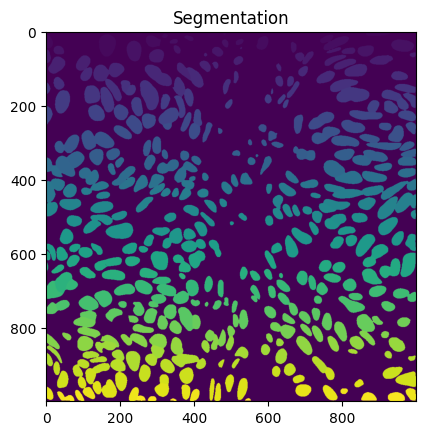

In [7]:
import matplotlib.pyplot as plt

plt.imshow(data["segmentation"])
plt.title("Segmentation")
plt.show()

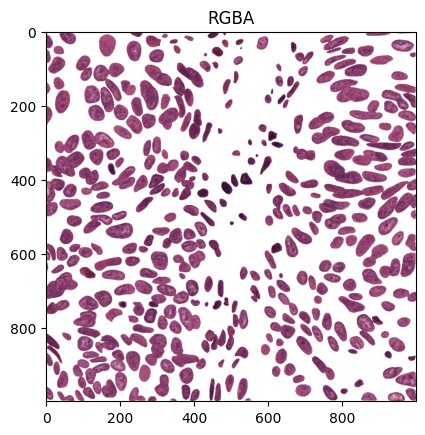

In [8]:
plt.imshow(data["rgba"])
plt.title("RGBA")
plt.show()

In [9]:
from src.io.output_writer import OutputWriter

writer = OutputWriter("outputs")

writer.save_all(data)
writer.save_rgba(data["id"], data["rgba"])

In [10]:
print(data["image"].dtype, data["image"].min(), data["image"].max())

uint8 8 255


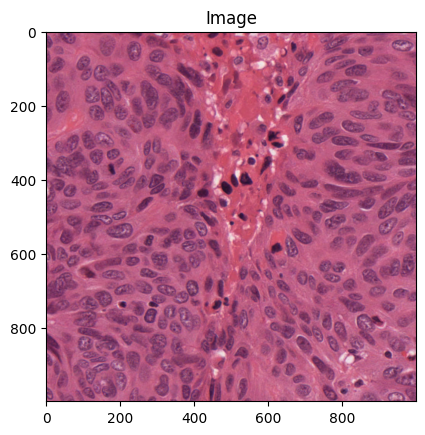

In [11]:
plt.imshow(data["image"])
plt.title("Image")
plt.show()

In [12]:
print(data["rgba"].shape)

(1000, 1000, 4)


# Segmentation models

In [13]:
import segmentation_models_pytorch as smp

In [14]:
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
    activation=None
)

model.eval()  # importante: modo inferência

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [15]:
import torch

rgba = data["rgba"]

x = torch.tensor(rgba).float() / 255.0   # normaliza
x = x.permute(2, 0, 1)                  # HWC → CHW
x = x.unsqueeze(0)                      # adiciona batch

print(x.shape)

torch.Size([1, 4, 1000, 1000])


In [16]:
with torch.no_grad():
    y = model(x)

In [17]:
print(y.shape)

torch.Size([1, 1, 1000, 1000])


In [18]:
pred = torch.sigmoid(y)
pred = pred.squeeze().cpu().numpy()

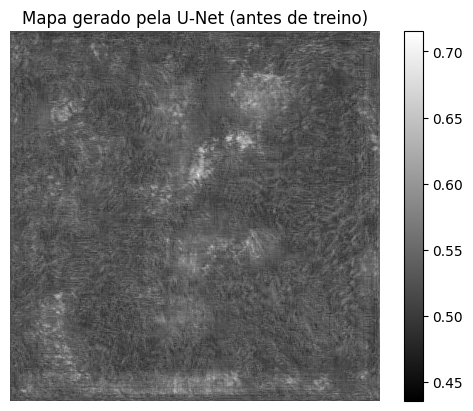

In [19]:
import matplotlib.pyplot as plt

plt.imshow(pred, cmap="gray")
plt.title("Mapa gerado pela U-Net (antes de treino)")
plt.colorbar()
plt.axis("off")
plt.show()

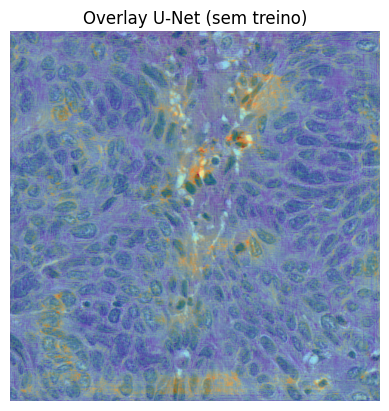

In [20]:
img = data["image"]

heatmap = (pred * 255).astype("uint8")

plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Overlay U-Net (sem treino)")
plt.axis("off")
plt.show()